# **Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, KFold
from keras.utils import to_categorical
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/DATASET/traffic.csv')

# Tampilkan 5 data pertama
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


# EDA

In [ ]:
# Drop kolom BusCount
if 'BusCount' in df.columns:
    df.drop(columns='BusCount', inplace=True)

df

,Time,Date,Day of the week,CarCount,BikeCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,16,94,normal
...,...,...,...,...,...,...,...,...
2971,10:45:00 PM,9,Thursday,16,3,36,56,normal
2972,11:00:00 PM,9,Thursday,11,0,30,42,normal
2973,11:15:00 PM,9,Thursday,15,4,25,45,normal
2974,11:30:00 PM,9,Thursday,16,5,27,48,normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   TruckCount         2976 non-null   int64 
 6   Total              2976 non-null   int64 
 7   Traffic Situation  2976 non-null   object
dtypes: int64(5), object(3)
memory usage: 186.1+ KB


In [ ]:
# Statistik deskriptif
df.describe()

,Date,CarCount,BikeCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.324933,114.218414
std,8.945775,45.850693,12.847518,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,40.000000,279.000000


In [ ]:
df.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [ ]:
# cek data duplikat
df.duplicated().sum()

np.int64(0)

# Outlier

Jumlah outlier per fitur:
- CarCount: 0 outlier
- BikeCount: 77 outlier
- TruckCount: 0 outlier
- Total: 0 outlier


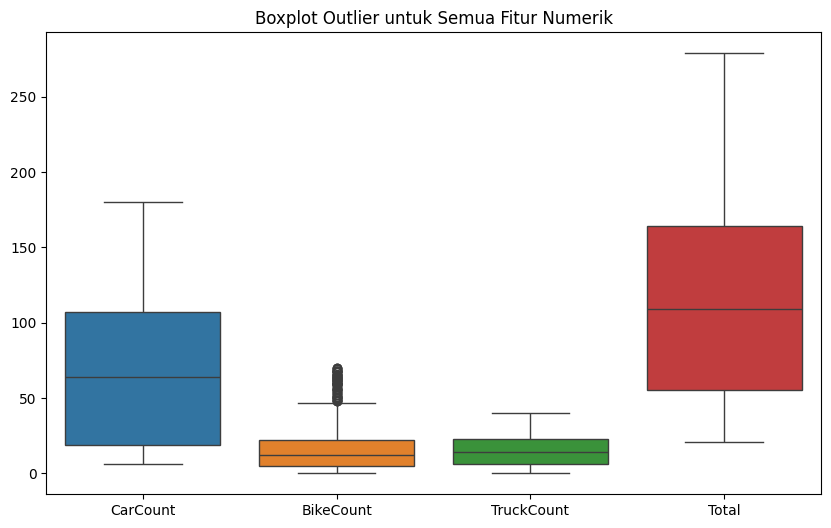

In [ ]:
# Hitung outlier IQR method untuk semua fitur numerik
numeric_cols = ['CarCount', 'BikeCount', 'TruckCount', 'Total']
outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

# Tampilkan total outlier
print("Jumlah outlier per fitur:")
for k, v in outlier_counts.items():
    print(f"- {k}: {v} outlier")

# Visualisasi boxplot (outlier)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot Outlier untuk Semua Fitur Numerik")
plt.show()


In [ ]:
# Hapus outlier pada kolom BikeCount menggunakan IQR
Q1 = df['BikeCount'].quantile(0.25)
Q3 = df['BikeCount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Filter data agar hanya menyisakan baris tanpa outlier pada BikeCount
df = df[(df['BikeCount'] >= lower) & (df['BikeCount'] <= upper)]

# Cek ukuran data setelah penghapusan
print(f"Jumlah data setelah hapus outlier BikeCount: {len(df)}")


Jumlah data setelah hapus outlier BikeCount: 2899


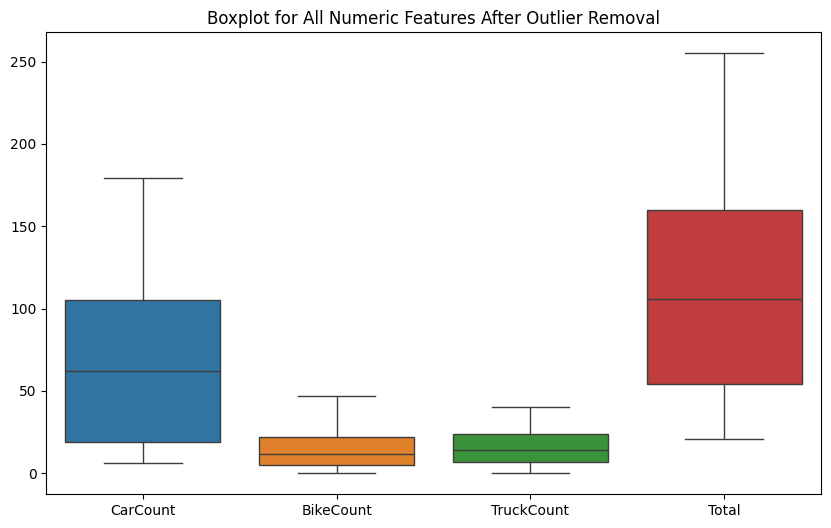

In [ ]:
# Visualisasi boxplot setelah penghapusan outlier BikeCount
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['CarCount', 'BikeCount', 'TruckCount', 'Total']])
plt.title("Boxplot for All Numeric Features After Outlier Removal")
plt.show()

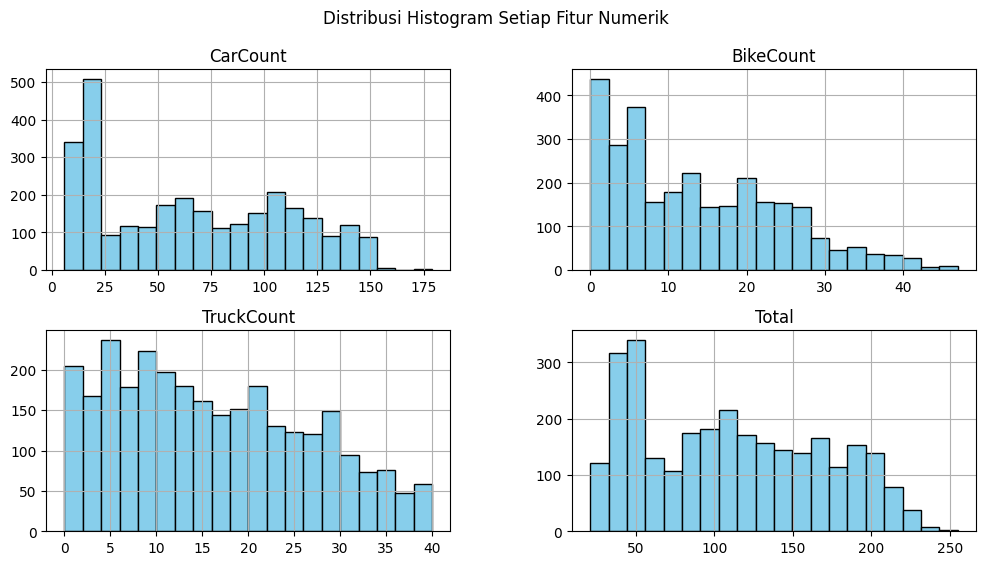

In [ ]:
df[numeric_cols].hist(bins=20, figsize=(12, 6), color='skyblue', edgecolor='black')
plt.suptitle("Distribusi Histogram Setiap Fitur Numerik")
plt.show()


# Eksplorasi distribusi data kategorik

In [ ]:
# Cek distribusi kolom kategorik
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\nDistribusi nilai pada kolom '{col}':")
    print(df[col].value_counts())



Distribusi nilai pada kolom 'Time':
Time
12:00:00 AM    31
12:15:00 AM    31
12:30:00 AM    31
12:45:00 AM    31
1:00:00 AM     31
               ..
1:45:00 PM     27
12:45:00 PM    27
1:00:00 PM     27
9:30:00 AM     27
11:30:00 AM    27
Name: count, Length: 96, dtype: int64

Distribusi nilai pada kolom 'Day of the week':
Day of the week
Tuesday      480
Wednesday    480
Thursday     480
Saturday     384
Sunday       384
Monday       384
Friday       307
Name: count, dtype: int64

Distribusi nilai pada kolom 'Traffic Situation':
Traffic Situation
normal    1669
heavy      605
high       321
low        304
Name: count, dtype: int64


/tmp/ipython-input-12-4206268862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Traffic Situation', data=df, palette='viridis')


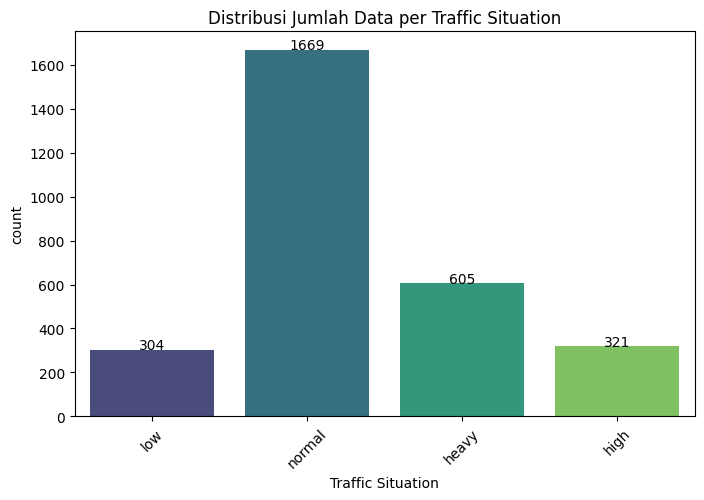

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Traffic Situation', data=df, palette='viridis')

# Tambahkan angka di atas setiap bar
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 1,
            f'{int(height)}', ha="center")

plt.title("Distribusi Jumlah Data per Traffic Situation")
plt.xticks(rotation=45)
plt.show()


# Preprocessing

In [ ]:
# ==== Feature Engineering ====
# Convert 'Time' to numeric (hour)
df.loc[:, 'Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour

# Convert 'Day of the week' to numeric
day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3,
           'Friday':4, 'Saturday':5, 'Sunday':6}
df.loc[:, 'DayIndex'] = df['Day of the week'].map(day_map)


/tmp/ipython-input-13-3384498655.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
/tmp/ipython-input-13-3384498655.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'DayIndex'] = df['Day of the week'].map(day_map)


In [ ]:
# ==== Encoding Target ====
label_encoder = LabelEncoder()
df.loc[:, 'TrafficSituationEncoded'] = label_encoder.fit_transform(df['Traffic Situation'])

/tmp/ipython-input-14-1888182829.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'TrafficSituationEncoded'] = label_encoder.fit_transform(df['Traffic Situation'])


In [ ]:
# ==== Define Features and Target ====
X = df[['Hour', 'DayIndex', 'CarCount', 'BikeCount', 'TruckCount', 'Total']]
y = df['TrafficSituationEncoded']

In [ ]:
# ==== Standardize Features ====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ==== Simpan Scaler ====
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

# Random Undersampling

/tmp/ipython-input-18-3333951890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette='Blues')


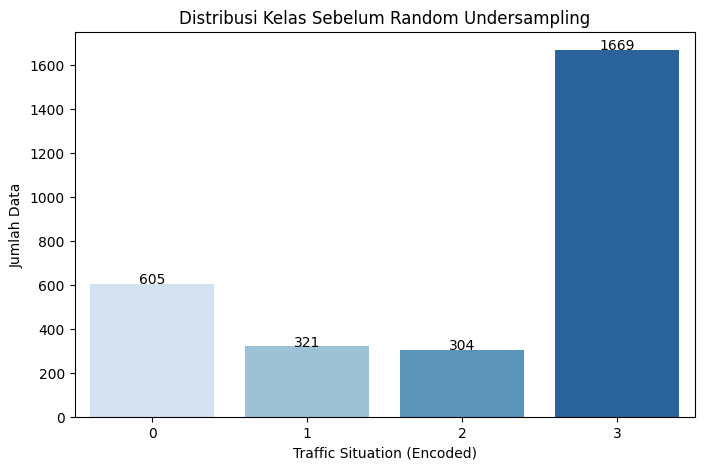

In [ ]:
# Hitung distribusi kelas sebelum undersampling
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y, palette='Blues')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 1,
            f'{int(height)}', ha="center")

plt.title("Distribusi Kelas Sebelum Random Undersampling")
plt.xlabel("Traffic Situation (Encoded)")
plt.ylabel("Jumlah Data")
plt.show()

In [ ]:
# ==== Random Undersampling ====
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_scaled, y)

# ==== Cek distribusi kelas setelah undersampling ====
import numpy as np
unique, counts = np.unique(y_resampled, return_counts=True)
print("Distribusi kelas setelah Random Undersampling:")
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} data")

# X_resampled dan y_resampled sekarang siap untuk split dan eksperimen

Distribusi kelas setelah Random Undersampling:
Class 0: 304 data
Class 1: 304 data
Class 2: 304 data
Class 3: 304 data


/tmp/ipython-input-20-3282931974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_resampled, palette='Greens')


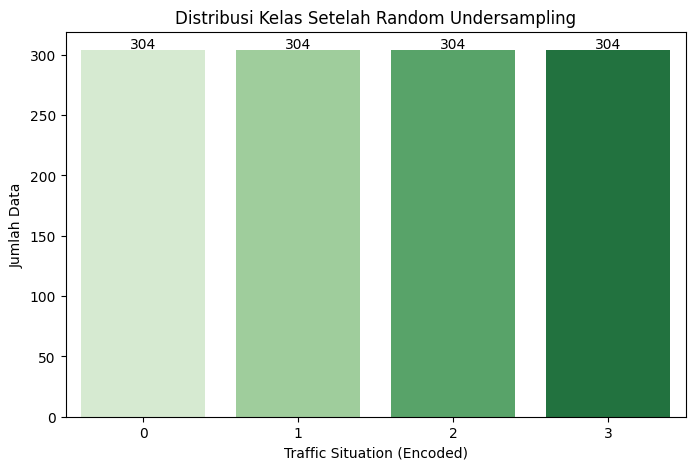

In [ ]:
# Hitung distribusi kelas setelah undersampling
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y_resampled, palette='Greens')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 1,
            f'{int(height)}', ha="center")

plt.title("Distribusi Kelas Setelah Random Undersampling")
plt.xlabel("Traffic Situation (Encoded)")
plt.ylabel("Jumlah Data")
plt.show()


# **Split Data untuk Eksperimen**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)


In [ ]:
# Bentuk input 3D untuk LSTM (samples, timesteps, features)
X_lstm_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_lstm_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


In [ ]:
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_lstm_train:", X_lstm_train.shape)
print("Jumlah kelas setelah split:", np.unique(y_train, return_counts=True))


Ukuran X_train: (972, 6)
Ukuran X_lstm_train: (972, 1, 6)
Jumlah kelas setelah split: (array([0, 1, 2, 3]), array([243, 243, 243, 243]))


# **Eksperimen 1**

In [ ]:
# === Model non-LSTM ===
models = {
    'ANN': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

k_range = range(2, 11)
accuracy_results = {name: [] for name in models.keys()}
accuracy_results['LSTM'] = []

# === Evaluasi model non-LSTM ===
for k in k_range:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
        accuracy_results[name].append(np.mean(scores))

# === Evaluasi LSTM manual ===
for k in k_range:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_accuracies = []

    for train_index, val_index in kf.split(X_lstm_train):
        X_fold_train, X_fold_val = X_lstm_train[train_index], X_lstm_train[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

        model = Sequential()
        model.add(LSTM(50, input_shape=(X_fold_train.shape[1], X_fold_train.shape[2])))
        model.add(Dense(len(np.unique(y_train)), activation='softmax'))
        model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

        model.fit(X_fold_train, y_fold_train, epochs=10, batch_size=32, verbose=0)

        y_pred_prob = model.predict(X_fold_val)
        y_pred = np.argmax(y_pred_prob, axis=1)
        acc = accuracy_score(y_fold_val, y_pred)
        fold_accuracies.append(acc)

    accuracy_results['LSTM'].append(np.mean(fold_accuracies))

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perce

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


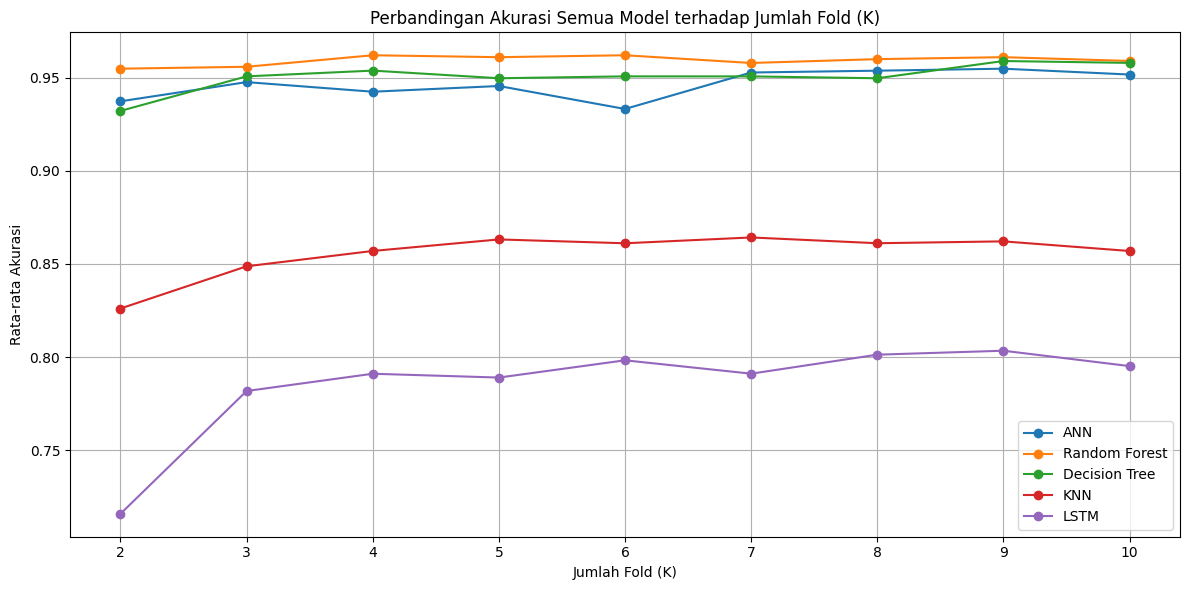

In [ ]:
# === Visualisasi ===
plt.figure(figsize=(12, 6))
for name, acc in accuracy_results.items():
    plt.plot(k_range, acc, marker='o', label=name)
plt.title('Perbandingan Akurasi Semua Model terhadap Jumlah Fold (K)')
plt.xlabel('Jumlah Fold (K)')
plt.ylabel('Rata-rata Akurasi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Buat DataFrame dari accuracy_results yang sudah ada
results_df = pd.DataFrame(accuracy_results, index=list(k_range))
results_df.index.name = 'Jumlah Fold (K)'
results_df

,ANN,Random Forest,Decision Tree,KNN,LSTM
Jumlah Fold (K),,,,,
2,0.937243,0.954733,0.932099,0.826132,0.716049
3,0.947531,0.955761,0.950617,0.848765,0.781893
4,0.942387,0.961934,0.953704,0.856996,0.791152
5,0.945445,0.960904,0.949611,0.863172,0.789104
6,0.933128,0.961934,0.950617,0.861111,0.798354
7,0.952686,0.957795,0.950601,0.864233,0.791188
8,0.953665,0.959855,0.949609,0.861138,0.801373
9,0.954733,0.960905,0.958848,0.862140,0.803498
10,0.951599,0.958879,0.957837,0.856975,0.795256


# **Eksperimen 2**

In [ ]:
# === K-Fold 9 ===
kf = KFold(n_splits=9, shuffle=True, random_state=42)

# === Model non-LSTM ===
models_exp2 = {
    'ANN': MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, early_stopping=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

# === Hasil Akurasi ===
exp2_results = {}

# === Evaluasi Model non-LSTM ===
for name, model in models_exp2.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    exp2_results[name] = round(np.mean(scores), 4)

# === Evaluasi LSTM manual ===
lstm_fold_accuracies = []
for train_index, val_index in kf.split(X_lstm_train):
    X_fold_train, X_fold_val = X_lstm_train[train_index], X_lstm_train[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

    model = Sequential()
    model.add(LSTM(50, input_shape=(X_fold_train.shape[1], X_fold_train.shape[2])))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    model.fit(X_fold_train, y_fold_train, epochs=10, batch_size=32, verbose=0)

    y_pred_prob = model.predict(X_fold_val)
    y_pred = np.argmax(y_pred_prob, axis=1)
    acc = accuracy_score(y_fold_val, y_pred)
    lstm_fold_accuracies.append(acc)

# Simpan hasil LSTM
exp2_results['LSTM'] = round(np.mean(lstm_fold_accuracies), 4)

# Tampilkan hasil
exp2_df = pd.DataFrame(list(exp2_results.items()), columns=["Model", "Rata-rata Akurasi (K=9)"])
print(exp2_df)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
           Model  Rata-rata Akurasi (K=9)
0            ANN                   0.7809
1  Random Forest                   0.9609
2  Decision Tree                   0.9588
3            KNN                   0.8621
4           LSTM                   0.7973


/tmp/ipython-input-28-200961441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp2_df, x="Model", y="Rata-rata Akurasi (K=9)", palette='crest')


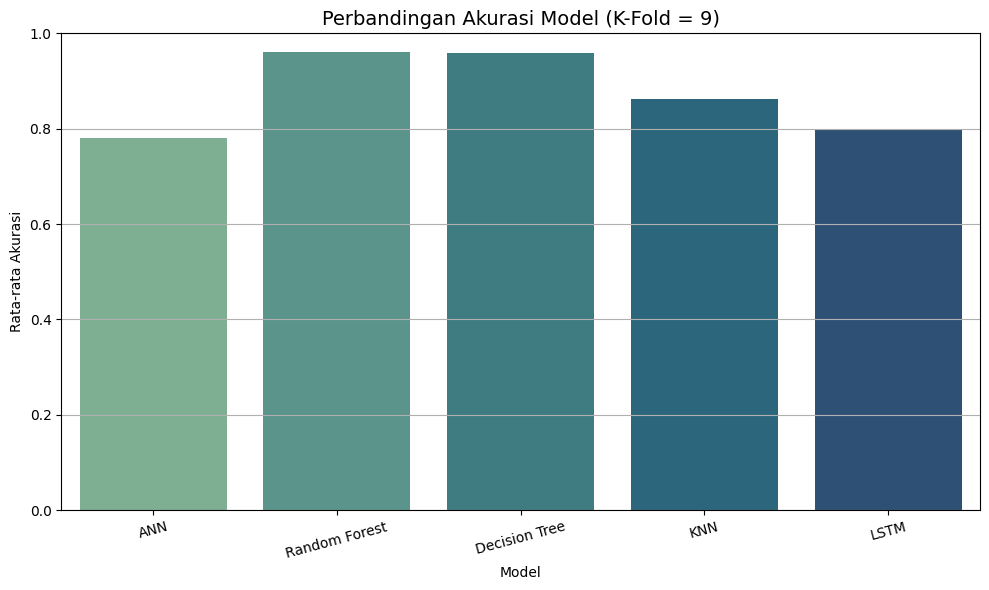

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=exp2_df, x="Model", y="Rata-rata Akurasi (K=9)", palette='crest')

plt.title("Perbandingan Akurasi Model (K-Fold = 9)", fontsize=14)
plt.ylabel("Rata-rata Akurasi")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# **Eksperimen 3**

In [ ]:
# Rasio train-test yang akan diuji
ratios = [0.6, 0.7, 0.8, 0.9]
rf_k9_results = {}

# Loop setiap rasio
for ratio in ratios:
    X_train_ratio, X_test_ratio, y_train_ratio, y_test_ratio = train_test_split(
        X_resampled, y_resampled, test_size=1 - ratio, random_state=42, stratify=y_resampled
    )

    # K-Fold = 9 untuk model ini
    kf = KFold(n_splits=9, shuffle=True, random_state=42)
    fold_accuracies = []

    for train_idx, val_idx in kf.split(X_train_ratio):
        X_fold_train, X_fold_val = X_train_ratio[train_idx], X_train_ratio[val_idx]
        y_fold_train, y_fold_val = y_train_ratio.iloc[train_idx], y_train_ratio.iloc[val_idx]

        model = RandomForestClassifier(random_state=42)
        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)
        acc = accuracy_score(y_fold_val, y_pred)
        fold_accuracies.append(acc)

    rf_k9_results[f"{int(round(ratio*100))}:{int(round((1-ratio)*100))}"] = round(np.mean(fold_accuracies), 4)

# Buat DataFrame hasil eksperimen 3
exp3_df = pd.DataFrame(list(rf_k9_results.items()), columns=["Rasio Data (Train:Test)", "Rata-rata Akurasi (RF, K=9)"])
exp3_df

,Rasio Data (Train:Test),"Rata-rata Akurasi (RF, K=9)"
0,60:40,0.9534
1,70:30,0.9542
2,80:20,0.9609
3,90:10,0.9607


/tmp/ipython-input-30-3899331671.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp3_df, x="Rasio Data (Train:Test)", y="Rata-rata Akurasi (RF, K=9)", palette='mako')


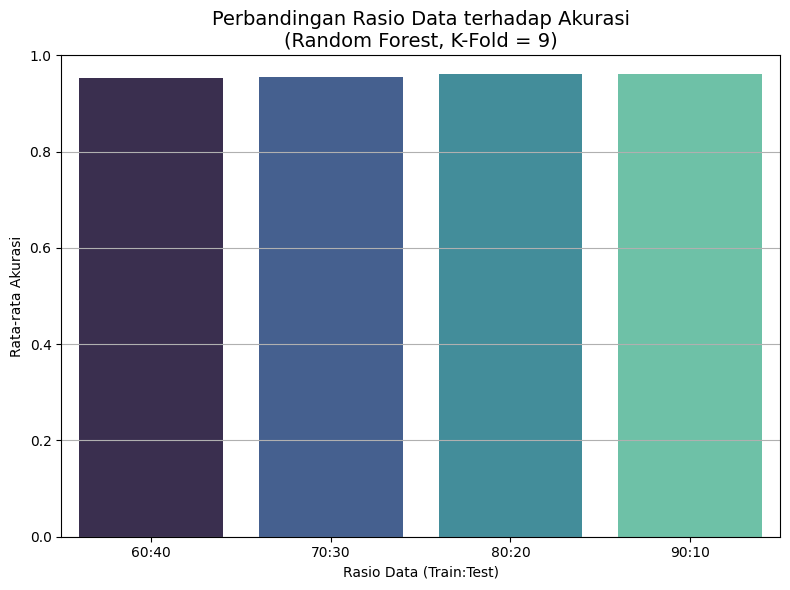

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=exp3_df, x="Rasio Data (Train:Test)", y="Rata-rata Akurasi (RF, K=9)", palette='mako')

plt.title("Perbandingan Rasio Data terhadap Akurasi\n(Random Forest, K-Fold = 9)", fontsize=14)
plt.ylabel("Rata-rata Akurasi")
plt.xlabel("Rasio Data (Train:Test)")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# **Eksperimen 4**

## gk dipake

In [ ]:
# VER 1
# Konfigurasi hyperparameter yang diuji
param_grid = [
    {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 150, 'max_depth': 10, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 20, 'max_features': 'log2'},
    {'n_estimators': 300, 'max_depth': None, 'max_features': None}
]

# K-Fold Cross Validation 9-Fold
kf = KFold(n_splits=9, shuffle=True, random_state=42)
hyperparam_results = []

for params in param_grid:
    fold_accuracies = []

    for train_idx, val_idx in kf.split(X_train):
        # Ambil data dari hasil train-test split 80:20 sebelumnya
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Inisialisasi dan training model dengan parameter saat ini
        model = RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            max_features=params['max_features'],
            random_state=42
        )

        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)
        acc = accuracy_score(y_fold_val, y_pred)
        fold_accuracies.append(acc)

    # Simpan hasil rata-rata akurasi untuk setiap konfigurasi
    config = f"n={params['n_estimators']}, depth={params['max_depth']}, features={params['max_features']}"
    hyperparam_results.append((config, round(np.mean(fold_accuracies), 4)))

# Tampilkan hasil dalam bentuk DataFrame
exp4_df = pd.DataFrame(hyperparam_results, columns=["Konfigurasi Random Forest", "Rata-rata Akurasi (K=9)"])
print(exp4_df)

## dipake eks 4

In [ ]:
#VER 2

# === Train-Test Split 80:20 ===
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# === GridSearch Hyperparameter ===
param_grid = [
    {'n_estimators': [10], 'max_features': ['sqrt']},
    {'n_estimators': [100], 'max_features': ['sqrt']},
    {'n_estimators': [1000], 'max_features': ['sqrt']},
    {'n_estimators': [1500], 'max_features': ['sqrt']},
    {'n_estimators': [10], 'max_features': ['log2']},
    {'n_estimators': [100], 'max_features': ['log2']},
    {'n_estimators': [1000], 'max_features': ['log2']},
    {'n_estimators': [1500], 'max_features': ['log2']},
    {'n_estimators': [600], 'max_features': ['sqrt']},
    {'n_estimators': [1300], 'max_features': ['sqrt']},
    {'n_estimators': [400], 'max_features': ['sqrt']},
    {'n_estimators': [800], 'max_features': ['sqrt']},
    {'n_estimators': [900], 'max_features': ['sqrt']},
    {'n_estimators': [300], 'max_features': ['sqrt']},
    {'n_estimators': [500], 'max_features': ['sqrt']},
    {'n_estimators': [550], 'max_features': ['sqrt']},
    {'n_estimators': [325], 'max_features': ['sqrt']},
    {'n_estimators': [350], 'max_features': ['sqrt']},
    {'n_estimators': [450], 'max_features': ['sqrt']},
    {'n_estimators': [340], 'max_features': ['sqrt']},
    {'n_estimators': [380], 'max_features': ['sqrt']},
    {'n_estimators': [425], 'max_features': ['sqrt']},
    {'n_estimators': [91], 'max_features': [4]}
]


# === K-Fold 9 ===
kfold = KFold(n_splits=9, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)

# === Grid Search CV ===
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=kfold, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# === Hasil Terbaik ===
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy (Cross-Validation):", round(grid_search.best_score_, 4))

# === Tampilkan semua hasil ===
results_df = pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score']]
results_df = results_df.sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)
print(results_df.head(23))

Best Parameters: {'max_features': 4, 'n_estimators': 91}
Best Accuracy (Cross-Validation): 0.965
                                            params  mean_test_score
0          {'max_features': 4, 'n_estimators': 91}         0.965021
1    {'max_features': 'sqrt', 'n_estimators': 450}         0.961934
2    {'max_features': 'sqrt', 'n_estimators': 300}         0.961934
3    {'max_features': 'sqrt', 'n_estimators': 800}         0.961934
4    {'max_features': 'sqrt', 'n_estimators': 550}         0.961934
5    {'max_features': 'sqrt', 'n_estimators': 600}         0.961934
6   {'max_features': 'sqrt', 'n_estimators': 1000}         0.961934
7   {'max_features': 'sqrt', 'n_estimators': 1300}         0.961934
8   {'max_features': 'log2', 'n_estimators': 1000}         0.961934
9    {'max_features': 'sqrt', 'n_estimators': 900}         0.961934
10  {'max_features': 'log2', 'n_estimators': 1500}         0.961934
11  {'max_features': 'sqrt', 'n_estimators': 1500}         0.961934
12   {'max_features

In [ ]:
# Pastikan X_train dan y_train sudah hasil split 80:20 dari X_resampled, y_resampled

# Konfigurasi model terbaik dari GridSearchCV (Eksperimen 4)
best_params = {'n_estimators': 91, 'max_features': 4}

# K-Fold 9
kf = KFold(n_splits=9, shuffle=True, random_state=42)
fold_accuracies = []

# Cross-validation untuk memastikan konsistensi performa
for train_idx, val_idx in kf.split(X_train):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_features=best_params['max_features'],
        random_state=42
    )

    model.fit(X_fold_train, y_fold_train)
    y_pred = model.predict(X_fold_val)
    acc = accuracy_score(y_fold_val, y_pred)
    fold_accuracies.append(acc)

print(f"Rata-rata akurasi cross-validation (9-fold): {np.mean(fold_accuracies):.4f}")

# Latih model akhir pada seluruh data training
best_rf_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_features=best_params['max_features'],
    random_state=42
)
best_rf_model.fit(X_train, y_train)

# Simpan model ke file
joblib.dump(best_rf_model, 'best_rf_model.joblib')
print("✅ Model terbaik telah disimpan sebagai 'best_rf_model.joblib'")


Rata-rata akurasi cross-validation (9-fold): 0.9650
✅ Model terbaik telah disimpan sebagai 'best_rf_model.joblib'


In [ ]:
# Memuat model yang sudah disimpan
loaded_model = joblib.load('best_rf_model.joblib')

# Menggunakan model untuk prediksi
predictions = loaded_model.predict(X_test)
predictions

array([0, 0, 0, 3, 1, 1, 2, 2, 0, 0, 1, 3, 0, 2, 1, 3, 0, 3, 1, 3, 2, 0,
       2, 1, 3, 0, 2, 1, 0, 1, 0, 0, 3, 1, 3, 2, 0, 3, 0, 0, 0, 3, 2, 2,
       3, 3, 1, 1, 1, 3, 0, 2, 2, 1, 1, 1, 1, 0, 1, 2, 2, 3, 0, 0, 3, 2,
       2, 2, 2, 3, 0, 3, 3, 0, 3, 2, 3, 1, 2, 0, 2, 1, 1, 2, 2, 2, 1, 1,
       2, 0, 0, 1, 1, 0, 3, 1, 1, 0, 2, 1, 3, 1, 1, 1, 1, 3, 1, 1, 0, 2,
       2, 1, 2, 1, 2, 3, 1, 0, 0, 0, 2, 2, 3, 1, 1, 1, 0, 3, 3, 0, 3, 2,
       3, 3, 1, 0, 1, 3, 2, 3, 3, 2, 1, 0, 0, 3, 0, 2, 3, 0, 3, 0, 0, 2,
       3, 2, 0, 1, 3, 3, 2, 1, 2, 1, 0, 1, 0, 2, 1, 3, 3, 0, 0, 2, 3, 3,
       3, 0, 1, 3, 1, 0, 0, 1, 0, 2, 3, 1, 1, 2, 0, 2, 2, 2, 3, 2, 3, 2,
       3, 2, 1, 3, 2, 1, 2, 3, 2, 2, 2, 1, 3, 2, 0, 1, 0, 3, 0, 1, 0, 1,
       2, 0, 3, 2, 1, 2, 2, 1, 1, 3, 0, 0, 0, 0, 2, 3, 3, 0, 1, 2, 1, 2,
       2, 0])

# **Evaluasi**

In [ ]:
# Memuat model terbaik yang sudah disimpan
best_rf_model = joblib.load('best_rf_model.joblib')

# Prediksi menggunakan model terbaik pada data test
y_pred = best_rf_model.predict(X_test)

# Evaluasi akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy:.4f}")


Akurasi: 0.9836


In [ ]:
# Memuat model terbaik yang sudah disimpan
best_rf_model = joblib.load('best_rf_model.joblib')

# Melakukan prediksi pada data test
y_pred = best_rf_model.predict(X_test)

# Evaluasi akurasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Cetak hasil evaluasi
print(f"Akurasi  : {accuracy:.4f}")
print(f"Presisi  : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Cetak classification report lengkap
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Akurasi  : 0.9836
Presisi  : 0.9841
Recall   : 0.9836
F1-Score : 0.9835

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       0.97      1.00      0.98        61
           2       0.97      1.00      0.98        61
           3       1.00      0.93      0.97        61

    accuracy                           0.98       244
   macro avg       0.98      0.98      0.98       244
weighted avg       0.98      0.98      0.98       244



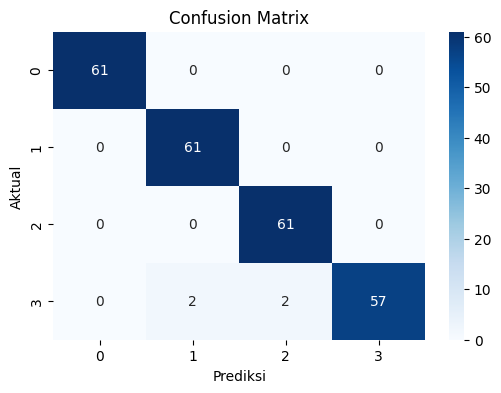

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_rf_model.classes_, yticklabels=best_rf_model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       0.97      1.00      0.98        61
           2       0.97      1.00      0.98        61
           3       1.00      0.93      0.97        61

    accuracy                           0.98       244
   macro avg       0.98      0.98      0.98       244
weighted avg       0.98      0.98      0.98       244



# **user input**

In [ ]:
# VER 1
# Memuat model Random Forest yang telah disimpan
best_rf_model = joblib.load('best_random_forest_model.joblib')

# Fungsi untuk mengonversi hari menjadi indeks
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}

# Input dari pengguna
jam = int(input("Masukkan jam (0-23): "))  # Input jam (0-23)
hari = input("Masukkan hari (misal: Monday): ")  # Input hari (misal: Monday)

# Validasi input hari
if hari not in day_map:
    print("Hari yang dimasukkan tidak valid!")
else:
    # Mengonversi hari ke indeks
    day_index = day_map[hari]

    # Membuat fitur berdasarkan input
    input_features = np.array([[jam, day_index]])

    # Melakukan prediksi
    prediction = best_rf_model.predict(input_features)

    # Output prediksi
    if prediction == 0:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: low")
    elif prediction == 1:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: normal")
    elif prediction == 2:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: low")
    else:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: high")


Masukkan jam (0-23): 12
Masukkan hari (misal: Monday): Monday


ValueError: X has 2 features, but RandomForestClassifier is expecting 6 features as input.

In [ ]:
#VER 2
# Memuat model Random Forest yang telah disimpan
best_rf_model = joblib.load('best_random_forest_model.joblib')

# Fungsi untuk mengonversi hari menjadi indeks
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}

# Input dari pengguna
jam = int(input("Masukkan jam (0-23): "))  # Input jam (0-23)
hari = input("Masukkan hari (misal: Monday): ")  # Input hari (misal: Monday)

# Validasi input hari
if hari not in day_map:
    print("Hari yang dimasukkan tidak valid!")
else:
    # Mengonversi hari ke indeks
    day_index = day_map[hari]

    # Membuat fitur berdasarkan input
    # Menyusun input fitur dengan nilai default untuk 'CarCount', 'BikeCount', 'TruckCount', 'Total'
    # Untuk fitur-fitur ini, kita anggap data default (misal, 0 atau nilai lainnya jika relevan)
    input_features = np.array([[jam, day_index, 0, 0, 0, 0]])  # (Hour, DayIndex, CarCount, BikeCount, TruckCount, Total)

    # Melakukan prediksi
    prediction = best_rf_model.predict(input_features)

    # Output prediksi
    if prediction == 0:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: heavy")
    elif prediction == 1:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: high")
    elif prediction == 2:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: low")
    else:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: normal")


In [ ]:
# VER 3
# Memuat model Random Forest yang telah disimpan
best_rf_model = joblib.load('best_rf_model.joblib')

# Fungsi untuk mengonversi hari menjadi indeks
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}

# Input dari pengguna untuk 6 fitur
jam = int(input("Masukkan jam (0-23): "))  # Input jam (0-23)
hari = input("Masukkan hari (misal: Monday): ")  # Input hari (misal: Monday)

# Validasi input hari
if hari not in day_map:
    print("Hari yang dimasukkan tidak valid!")
else:
    # Mengonversi hari ke indeks
    day_index = day_map[hari]

    # Input untuk jumlah kendaraan
    car_count = int(input("Masukkan jumlah mobil: "))
    bike_count = int(input("Masukkan jumlah motor: "))
    truck_count = int(input("Masukkan jumlah truk: "))
    total_count = car_count + bike_count + truck_count

    # Membuat fitur berdasarkan input
    input_features = np.array([[jam, day_index, car_count, bike_count, truck_count, total_count]])

    # Melakukan prediksi
    prediction = best_rf_model.predict(input_features)

    # Output prediksi
    if prediction == 0:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: heavy")
    elif prediction == 1:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: high")
    elif prediction == 2:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: low")
    else:
        print(f"Prediksi tingkat kemacetan pada hari {hari} pukul {jam}:00 adalah: normal")


Masukkan jam (0-23): 15
Masukkan hari (misal: Monday): Tuesday
Masukkan jumlah mobil: 50
Masukkan jumlah motor: 0
Masukkan jumlah truk: 0
Prediksi tingkat kemacetan pada hari Tuesday pukul 15:00 adalah: heavy


In [ ]:
!pip show numpy scikit-learn

Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI

In [ ]:
import numpy
import sklearn

print(f"Versi NumPy: {numpy.__version__}")
print(f"Versi scikit-learn: {sklearn.__version__}")
import sys
print(sys.version)

Versi NumPy: 2.0.2
Versi scikit-learn: 1.6.1
3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
